## EDA Findings

The dataset contains 242,212 food price observations across 16 variables.
The observations cover multiple Philippine markets, commodities, food
categories, units, and price types.

The target variable, price, shows variation across commodities, markets,
units, and time. The price distribution should be investigated for skewness
and extreme observations before model training.

The dataset contains categorical variables such as commodity, market,
category, unit, and price type that may provide important information for
price prediction. The date variable also provides temporal information and
will be transformed into appropriate time-based features.

Identifier variables such as market_id and commodity_id are initially
excluded because their information is already represented by market and
commodity. The currency variable is excluded if it contains only PHP.
The usdprice variable is excluded because it represents the same underlying
price information and could cause target leakage.

Because the dataset is time-ordered, the modeling stage will use a
chronological train-test split rather than randomly shuffling observations.

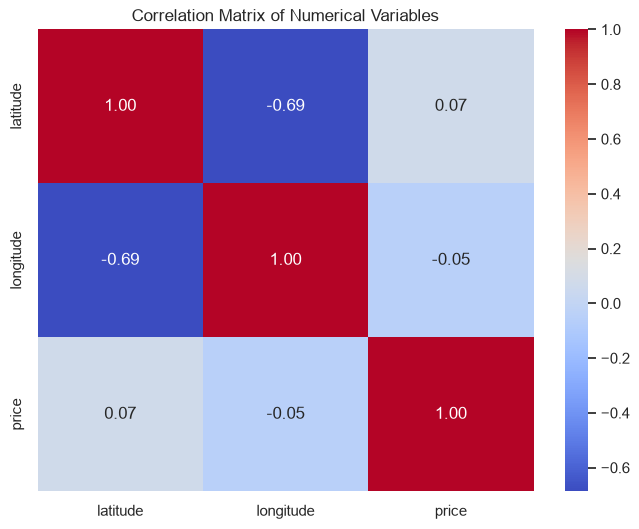

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [32]:
numeric_columns = [
    "latitude",
    "longitude",
    "price"
]

correlation = df[numeric_columns].corr()

correlation

,latitude,longitude,price
latitude,1.000000,-0.687057,0.072967
longitude,-0.687057,1.000000,-0.048588
price,0.072967,-0.048588,1.000000


In [31]:
print("Admin 1:", df["admin1"].nunique())
print("Admin 2:", df["admin2"].nunique())
print("Markets:", df["market"].nunique())
df.groupby("admin1")["price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)


Admin 1: 17
Admin 2: 79
Markets: 108


,count,mean,median
admin1,,,
Region IV-A,14741,154.951144,104.250
Region III,21518,153.462720,107.500
Region IV-B,14562,143.395779,110.000
Region VIII,17256,141.175030,111.225
Region VI,17682,137.720881,103.750
National Capital region,5589,137.694060,89.010
Region V,17797,137.611244,108.000
Region XIII,14028,134.571196,93.750
Region I,11799,131.817232,91.380


In [29]:
print("Prices <= 0:", (df["price"] <= 0).sum())
print("Missing prices:", df["price"].isnull().sum())

Prices <= 0: 0
Missing prices: 0


In [27]:
df.nsmallest(20, "price")[
    [
        "date",
        "market",
        "commodity",
        "unit",
        "pricetype",
        "price"
    ]
]

,date,market,commodity,unit,pricetype,price
22261,2016-07-15,La Trinidad,Cabbage,KG,Wholesale,1.60
24477,2017-05-15,Metro Manila,Eggs,Unit,Wholesale,3.48
4209,2008-06-15,Metro Manila,Eggs,Unit,Retail,3.99
5877,2009-02-15,Koronadal,Eggs,Unit,Retail,4.00
6122,2009-03-15,Koronadal,Eggs,Unit,Retail,4.00
6369,2009-04-15,Koronadal,Eggs,Unit,Retail,4.00
6616,2009-05-15,Koronadal,Eggs,Unit,Retail,4.00
6863,2009-06-15,Koronadal,Eggs,Unit,Retail,4.00
4385,2008-07-15,Metro Manila,Eggs,Unit,Retail,4.01
7110,2009-07-15,Koronadal,Eggs,Unit,Retail,4.01


In [26]:
df.nlargest(20, "price")[
    [
        "date",
        "market",
        "commodity",
        "unit",
        "pricetype",
        "price"
    ]
]

,date,market,commodity,unit,pricetype,price
185248,2025-01-15,Pampanga,Shrimp (tiger),KG,Retail,1216.67
185313,2025-01-15,Tarlac,Shrimp (tiger),KG,Retail,1212.25
187833,2025-02-15,Tarlac,Shrimp (tiger),KG,Retail,1206.00
124857,2023-01-15,Tarlac,Shrimp (tiger),KG,Retail,1166.00
155104,2024-01-15,Zambales,Shrimp (tiger),KG,Retail,1130.00
192873,2025-04-15,Tarlac,Shrimp (tiger),KG,Retail,1127.25
157528,2024-02-15,Pampanga,Shrimp (tiger),KG,Retail,1125.00
124920,2023-01-15,Batangas,Shrimp (tiger),KG,Retail,1121.43
190353,2025-03-15,Tarlac,Shrimp (tiger),KG,Retail,1118.50
127438,2023-02-15,Batangas,Shrimp (tiger),KG,Retail,1114.29


In [25]:
df["unit"].value_counts()
df.groupby("unit")["price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
unit,,,,,
750 ML,133,53.445113,52.50,18.29,121.00
KG,234071,135.830872,97.50,1.60,1216.67
Unit,8008,7.793419,7.94,3.48,25.00


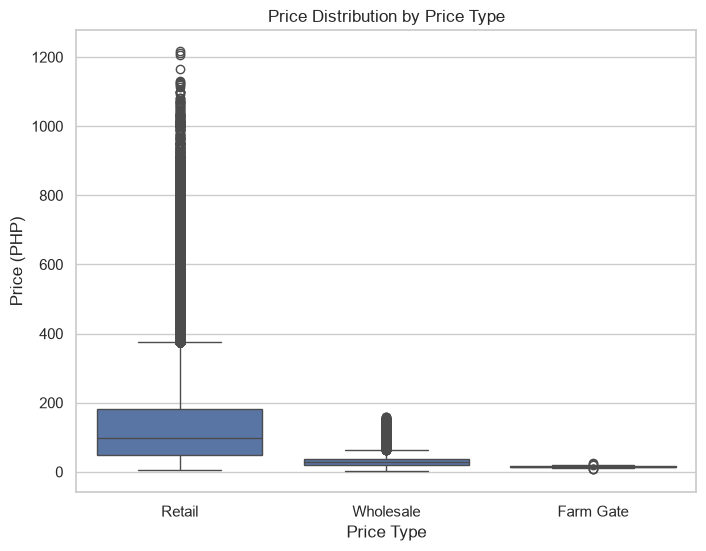

In [23]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="pricetype",
    y="price"
)

plt.title("Price Distribution by Price Type")
plt.xlabel("Price Type")
plt.ylabel("Price (PHP)")

plt.show()

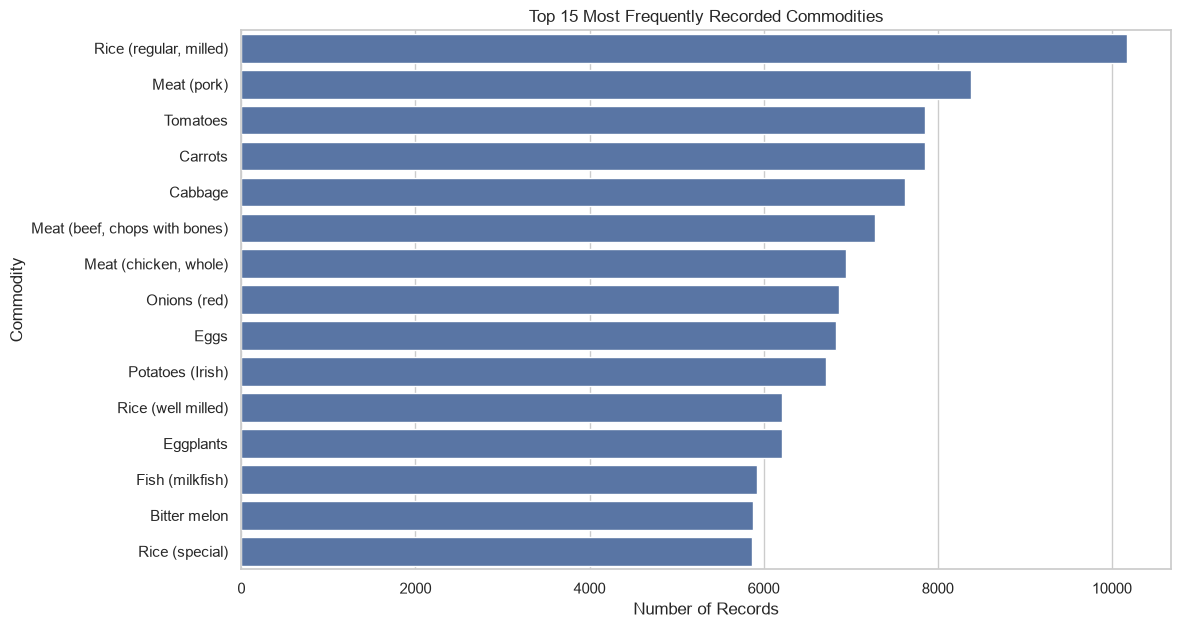

In [22]:
top_commodities = (
    df["commodity"]
    .value_counts()
    .head(15)
)

top_commodities
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_commodities.values,
    y=top_commodities.index
)

plt.title("Top 15 Most Frequently Recorded Commodities")
plt.xlabel("Number of Records")
plt.ylabel("Commodity")

plt.show()

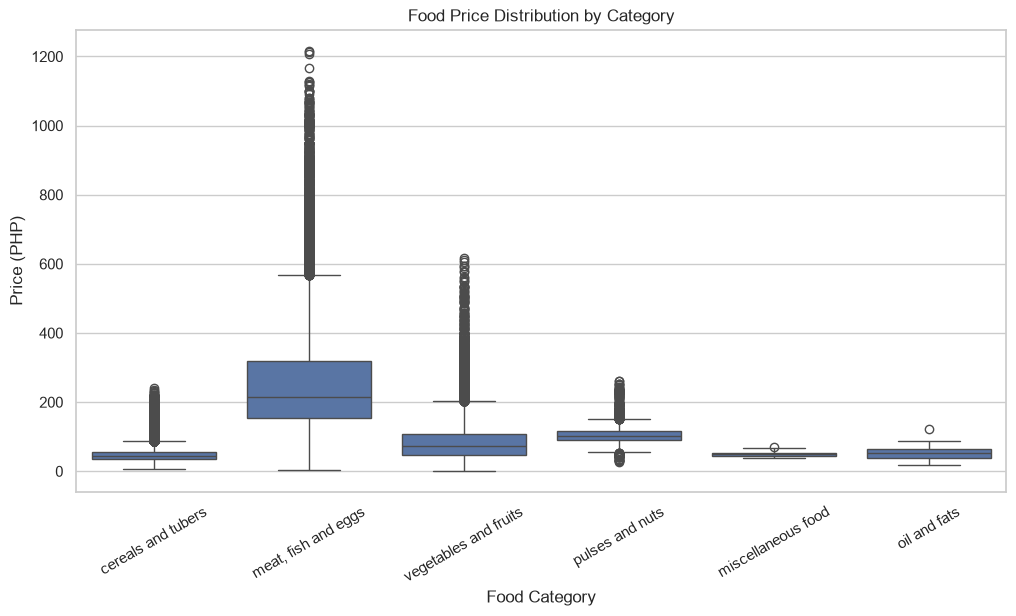

In [20]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="category",
    y="price"
)

plt.title("Food Price Distribution by Category")
plt.xlabel("Food Category")
plt.ylabel("Price (PHP)")

plt.xticks(rotation=30)

plt.show()

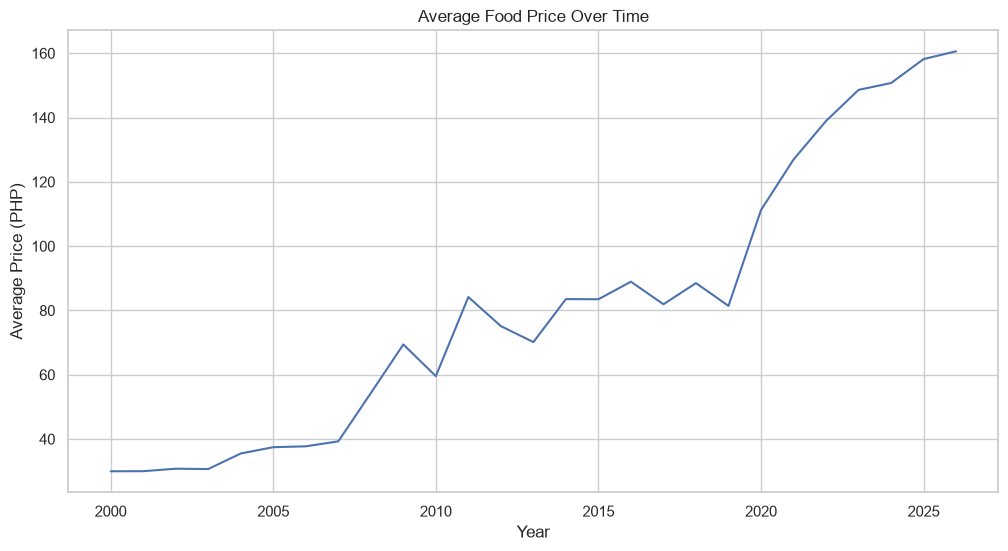

In [19]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_price,
    x="year",
    y="price"
)

plt.title("Average Food Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price (PHP)")

plt.show()

In [18]:
df["year"] = df["date"].dt.year
yearly_price = (
    df.groupby("year")["price"]
    .mean()
    .reset_index()
)

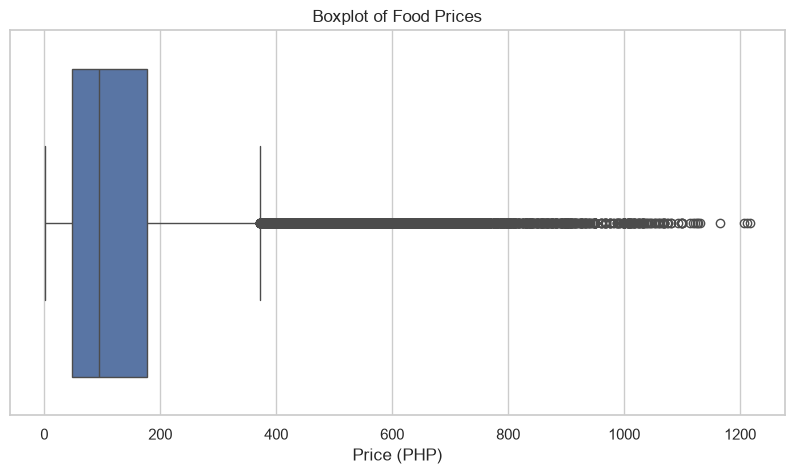

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["price"]
)

plt.title("Boxplot of Food Prices")
plt.xlabel("Price (PHP)")

plt.show()

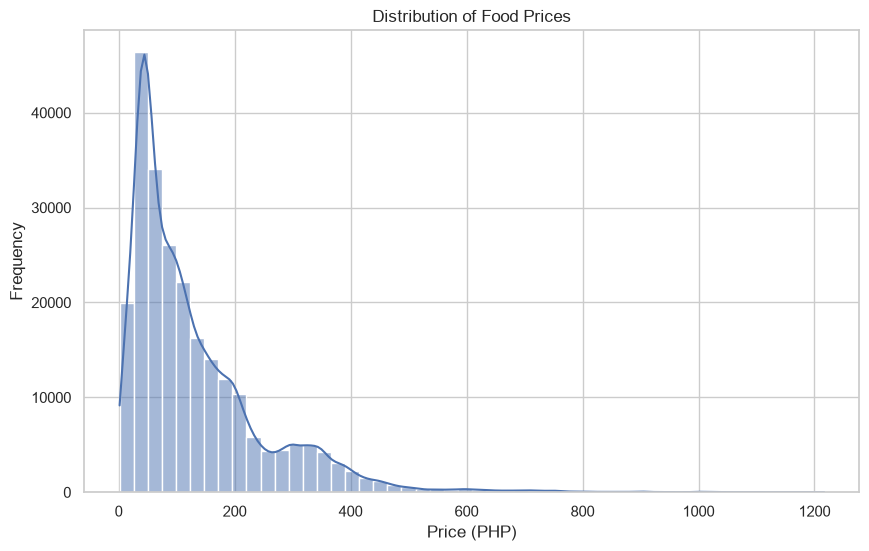

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Food Prices")
plt.xlabel("Price (PHP)")
plt.ylabel("Frequency")

plt.show()

In [14]:
df["price"].describe()
df["price"].quantile(
    [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]
)

0.00       1.6000
0.01       6.7500
0.05      18.7500
0.25      47.2900
0.50      93.7500
0.75     177.5000
0.95     366.6700
0.99     553.2156
1.00    1216.6700
Name: price, dtype: float64

In [12]:
categorical_columns = [
    "admin1",
    "admin2",
    "market",
    "category",
    "commodity",
    "unit",
    "priceflag",
    "pricetype",
    "currency"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print("Unique values:", df[column].nunique())
    print(df[column].value_counts().head(10))


admin1:
Unique values: 17
admin1
Region III                          21518
Region V                            17797
Region VI                           17682
Region VIII                         17256
Cordillera Administrative region    16135
Region XI                           15788
Region IV-A                         14741
Region IV-B                         14562
Region X                            14255
Region XIII                         14028
Name: count, dtype: int64

admin2:
Unique values: 79
admin2
Davao del Sur          8769
Zamboanga del Sur      7204
Bulacan                5691
Cebu                   5611
Metropolitan Manila    5589
Masbate                5531
Iloilo                 5411
South Cotabato         5385
Nueva Ecija            5038
Albay                  4814
Name: count, dtype: int64

market:
Unique values: 108
market
Metro Manila         5589
Davao City           5432
Zamboanga City       4102
Nueva Vizcaya        3105
Zamboanga del Sur    3102
Cebu City      

In [11]:
print("Earliest date:", df["date"].min())
print("Latest date:", df["date"].max())
print("Number of unique dates:", df["date"].nunique())

Earliest date: 2000-01-15 00:00:00
Latest date: 2026-08-15 00:00:00
Number of unique dates: 318


In [10]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [8]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [7]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,242212.000000,242212.000000,242212.000000,242212.000000,242212.000000,242212.000000
mean,3592.242824,11.728192,122.870537,479.736665,131.552466,2.442067
std,1564.812878,3.604282,1.913049,327.911023,119.382021,2.173712
min,167.000000,5.030000,118.740000,67.000000,1.600000,0.034000
25%,4269.000000,8.480000,121.090000,125.000000,47.290000,0.890000
50%,4293.000000,11.580000,122.760000,408.000000,93.750000,1.750000
75%,4318.000000,14.670000,124.650000,846.000000,177.500000,3.350000
max,5224.000000,18.190000,126.210000,874.000000,1216.670000,21.340000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 242212 entries, 0 to 242211
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          242212 non-null  str    
 1   admin1        242212 non-null  str    
 2   admin2        242212 non-null  str    
 3   market        242212 non-null  str    
 4   market_id     242212 non-null  int64  
 5   latitude      242212 non-null  float64
 6   longitude     242212 non-null  float64
 7   category      242212 non-null  str    
 8   commodity     242212 non-null  str    
 9   commodity_id  242212 non-null  int64  
 10  unit          242212 non-null  str    
 11  priceflag     242212 non-null  str    
 12  pricetype     242212 non-null  str    
 13  currency      242212 non-null  str    
 14  price         242212 non-null  float64
 15  usdprice      242212 non-null  float64
dtypes: float64(4), int64(2), str(10)
memory usage: 51.3 MB


In [5]:
df.columns.tolist()

['date',
 'admin1',
 'admin2',
 'market',
 'market_id',
 'latitude',
 'longitude',
 'category',
 'commodity',
 'commodity_id',
 'unit',
 'priceflag',
 'pricetype',
 'currency',
 'price',
 'usdprice']

## 1. Dataset Overview

The dataset contains historical food price observations from the Philippines.
The initial dataset contains 242,212 records and 16 variables.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 242212
Columns: 16


In [3]:
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.6,120.98,cereals and tubers,"Rice (milled, superior)",593,KG,actual,Retail,PHP,20.00,0.49
1,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.6,120.98,cereals and tubers,"Rice (milled, superior)",593,KG,actual,Wholesale,PHP,18.35,0.45
2,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.6,120.98,cereals and tubers,"Rice (regular, milled)",80,KG,actual,Retail,PHP,18.00,0.44
3,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.6,120.98,cereals and tubers,"Rice (regular, milled)",80,KG,actual,Wholesale,PHP,16.35,0.40
4,2000-01-15,National Capital region,Metropolitan Manila,Metro Manila,167,14.6,120.98,"meat, fish and eggs",Meat (pork),140,KG,actual,Retail,PHP,105.37,2.60


In [2]:
df = pd.read_csv("../data/original/wfp_food_prices_phl.csv")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")